In [2]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study4.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_

In [3]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')



In [4]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study4.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = [
    "None",
    "Causal_Explanation",
    "stripes",
    "feet",
    "both",
    "other",
]

for col in coding_cols:
    df_coding[col] = (
        df_coding[col]
        .fillna(0)
        .replace("", 0)
        .astype(int)
    )


# Feature-specific causal indicators
# A tick in "both" means both stripes and feet are causal
df_coding["causal_stripes"] = (
    df_coding["stripes"].eq(1)
    | df_coding["both"].eq(1)
)

df_coding["causal_feet"] = (
    df_coding["feet"].eq(1)
    | df_coding["both"].eq(1)
)


# Another label for type of explanation: "stripes", "feet", "both", or "none"
df_coding["explanation_type"] = np.select(
    [
        df_coding["causal_stripes"] & df_coding["causal_feet"],
        df_coding["causal_stripes"],
        df_coding["causal_feet"],
    ],
    [
        "both",
        "stripes",
        "feet",
    ],
    default="none",
)


# Broad causal flag that there was a causal explanation of any kind
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1)
    | df_coding["causal_stripes"]
    | df_coding["causal_feet"]
)



# Merge coding onto accommodate data
df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "explanation_type",
            "has_causal_explanation",
            "causal_stripes",
            "causal_feet",
        ]
    ],
    on="participant",
    how="left",
    validate="many_to_one",
)


# Participants not in coding file default to no causal explanation
df_accommodate["explanation_type"] = (
    df_accommodate["explanation_type"]
    .fillna("none")
)

boolean_cols = [
    "has_causal_explanation",
    "causal_stripes",
    "causal_feet",
]

df_accommodate[boolean_cols] = (
    df_accommodate[boolean_cols]
    .fillna(False)
    .astype(bool)
)

In [5]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [6]:
participant_id = 220

row = df_accommodate.loc[
    df_accommodate['participant'] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal feet: {row['causal_feet']}")
print(f"Causal stripes: {row['causal_stripes']}")
print("\n--- FREE TEXTS ---\n")

for text in row['free_texts']:
    print(text)
    print()

Participant: 220
Explanation type: both
Has causal explanation: True
Causal feet: True
Causal stripes: True

--- FREE TEXTS ---

This lizard is short, without a lengthy tail and a bit unattractive with its stripe, so mates are not as aroused by its physical features, resulting in a lower score than average, but not zero.

This lizard has 16 strips, more than average, making it more attractive as a potential mate.

This lizard has 16 stripes, making it quite attractive as a mate.

This lizard has 20 stripes going a non-traditional way, top angling back toward the tail, making it not overly attractive to mates.

This lizard has 16 strips, all angling toward the head, yet something about it keeps mates ambivalent toward it.

This lizard has light toes, making at attractive for mating.

This lizard has pointy toes and strips angling back toward its tail (at the top), so it is mediocre, kinda hum-drum.

This lizard has recessive stripes going back toward the tail, but it also has rounded to

In [7]:
# Create map from feature response labels to internal short codes

feet_map = {
    "webbed": "f",
    "curved/pointy": "c",
}

stripes_map = {
    "up/right": "e",
    "up/left": "w",
}

feature_maps = {
    "feet": feet_map,
    "stripes": stripes_map,
}


# Compute feature importance scores

def compute_feature_importance_from_df(df):
    """
    Compute numeric feature-importance scores from -7 to 7.

    A score of 0 indicates that the participant said the feature was not
    relevant, did not respond, or selected a direction that could not be
    matched to the stored high/low feature values.
    """

    df = df.copy()
    features = ["feet", "stripes"]

    def normalize_str(value):
        """Strip whitespace, collapse repeated spaces, and lowercase strings."""
        if isinstance(value, str):
            return " ".join(value.split()).lower()
        return ""

    def compute_row_importance(row, feat):
        disc = row[f"{feat}_discrete_slider.response"]
        direction = row[f"{feat}_direction_slider.response"]
        continuous = row[f"{feat}_continuous_slider.response"]

        # If the participant said the feature was not relevant,
        # or did not answer, importance is zero
        if disc == "No" or pd.isna(disc):
            return 0.0

        # Missing continuous response defaults to zero
        cont_val = float(continuous) if not pd.isna(continuous) else 0.0

        mapping = feature_maps.get(feat, {})

        direction_norm = normalize_str(direction)
        internal_direction = mapping.get(direction_norm)

        high_val = normalize_str(row[f"{feat}_high"])
        low_val = normalize_str(row[f"{feat}_low"])

        # Positive if selected direction matches the true high value
        if internal_direction == high_val:
            sign = 1

        # Negative if selected direction matches the true low value
        elif internal_direction == low_val:
            sign = -1

        # Unmatched or missing response
        else:
            sign = 0
            cont_val = 0.0

        return cont_val * sign

    for feat in features:
        df[f"{feat}_importance"] = df.apply(
            lambda row: compute_row_importance(row, feat),
            axis=1,
        )

    return df


df_combined = compute_feature_importance_from_df(df_combined)


# Create participant-level explanation group:
# predict
# accommodate_causal
# accommodate_none

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)


# Reshape to long format:
# one row per participant × feature dimension

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "feet_importance",
    "stripes_importance",
    "explanation_type",
    "has_causal_explanation",
    "causal_feet",
    "causal_stripes",
    "relevant_dim",
    "irrelevant_dim",
    "feet_high",
    "stripes_high",
    "feet_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "explanation_type",
        "has_causal_explanation",
        "causal_feet",
        "causal_stripes",
        "relevant_dim",
        "irrelevant_dim",
        "feet_high",
        "stripes_high",
        "feet_discrete_slider.response",
    ],
    value_vars=[
        "feet_importance",
        "stripes_importance",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)


# Simplify feature-dimension names

df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance", "", regex=False)
)


# Create row-level indicator:
# Did this participant provide a causal explanation for this specific feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("feet"),
        df_long["feature_dimension"].eq("stripes"),
    ],
    [
        df_long["causal_feet"].fillna(False),
        df_long["causal_stripes"].fillna(False),
    ],
    default=False,
).astype(bool)

# Predictors should always be False
df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)


# Create feature-specific plotting group

df_long["feature_explanation_group"] = np.select(
    [
        df_long["task"].eq("predict"),
        (
            df_long["task"].eq("accommodate")
            & df_long["had_causal_explanation_for_feature"]
        ),
        (
            df_long["task"].eq("accommodate")
            & ~df_long["had_causal_explanation_for_feature"]
        ),
    ],
    [
        "predictor",
        "explainer",
        "non_explainer",
    ],
    default=pd.NA,
)


# Determine whether each feature was relevant

df_long["feature_relevance"] = np.where(
    df_long["feature_dimension"].eq(df_long["relevant_dim"]),
    "relevant",
    "irrelevant",
)





/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/4188002949.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/4188002949.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/4188002949.py:176: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a

In [8]:
# Features included in the overfitting/relevance count
features = ["feet", "stripes"]

discrete_cols = [
    f"{feat}_discrete_slider.response"
    for feat in features
]

# Inspect the response values before recoding
for col in discrete_cols:
    print(f"\nValues in {col}:")
    print(df_combined[col].value_counts(dropna=False))


Values in feet_discrete_slider.response:
feet_discrete_slider.response
No     209
Yes    199
Name: count, dtype: int64

Values in stripes_discrete_slider.response:
stripes_discrete_slider.response
Yes    208
No     200
Name: count, dtype: int64


  explanation_group  n_features_endorsed  n_participants  percentage
0         Predictor                    0              59   28.921569
1         Predictor                    1              79   38.725490
2         Predictor                    2              66   32.352941
3     Non-explainer                    0              45   32.608696
4     Non-explainer                    1              55   39.855072
5     Non-explainer                    2              38   27.536232
6         Explainer                    0              18   27.272727
7         Explainer                    1              31   46.969697
8         Explainer                    2              17   25.757576


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/884574513.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/884574513.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)


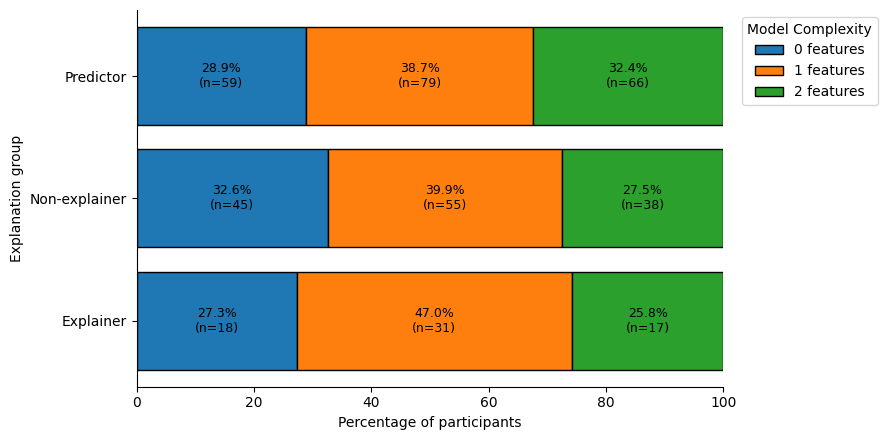

In [9]:
# Convert Yes/No response to 'does this feature matter' into 1/0 indicators
for feat in features:
    response_col = f"{feat}_discrete_slider.response"
    endorsed_col = f"{feat}_endorsed"

    df_combined[endorsed_col] = (
        df_combined[response_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# Total number of features judged relevant: 0, 1, or 2
df_combined["n_features_endorsed"] = (
    df_combined["feet_endorsed"]
    + df_combined["stripes_endorsed"]
)

# Create a new column for explanation group, based on task and causal explanation status
df_combined["explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),

        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),

        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "Predictor",
        "Explainer",
        "Non-explainer",
    ],
    default=pd.NA,
)
# Create a unique identifier for each participant × task combination
df_combined["participant_task_id"] = (
    df_combined["participant"].astype(str)
    + "_"
    + df_combined["task"].astype(str)
)
overfit_df = df_combined[
    [
        "participant",
        "participant_task_id",
        "task",
        "explanation_group",
        "feet_endorsed",
        "stripes_endorsed",
        "n_features_endorsed",
        "relevant_dim",
        "irrelevant_dim",
    ]
].copy()

# Plotting order
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

score_order = [0, 1, 2]


# Count participants at each score within each group
overfit_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "n_features_endorsed",
        ],
        observed=True
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique"
        )
    )
    .reset_index()
)


# If a group has no participants with a given score, we want to fill in that row with 0 participants
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        score_order,
    ],
    names=[
        "explanation_group",
        "n_features_endorsed",
    ]
)

overfit_percentages = (
    overfit_percentages
    .set_index(
        [
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)


# Calculate percentage within each explanation group
overfit_percentages["percentage"] = (
    overfit_percentages["n_participants"]
    / overfit_percentages
        .groupby("explanation_group")["n_participants"]
        .transform("sum")
    * 100
)

print(overfit_percentages)

count_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="n_participants"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .fillna(0)
)

# Convert long percentages table to wide format:
# one row per group, one column for each score
percentage_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="percentage"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .fillna(0)
)


fig, ax = plt.subplots(figsize=(9, 4.5))

left = np.zeros(len(percentage_wide))
#Plot horizontal stacked bar chart
for score in [0, 1, 2]:
    percentages = percentage_wide[score].to_numpy()
    counts = count_wide[score].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=f"{score} features",
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        if percentage >= 8:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )
        elif percentage > 0:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))
ax.invert_yaxis()

ax.legend(
    title="Model Complexity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

   explanation_group endorsement_pattern  n_participants  percentage
0          Predictor          0 features              59   28.921569
1          Predictor             1: feet              33   16.176471
2          Predictor          1: stripes              46   22.549020
3          Predictor          2 features              66   32.352941
4      Non-explainer          0 features              45   32.608696
5      Non-explainer             1: feet              21   15.217391
6      Non-explainer          1: stripes              34   24.637681
7      Non-explainer          2 features              38   27.536232
8          Explainer          0 features              18   27.272727
9          Explainer             1: feet              24   36.363636
10         Explainer          1: stripes               7   10.606061
11         Explainer          2 features              17   25.757576


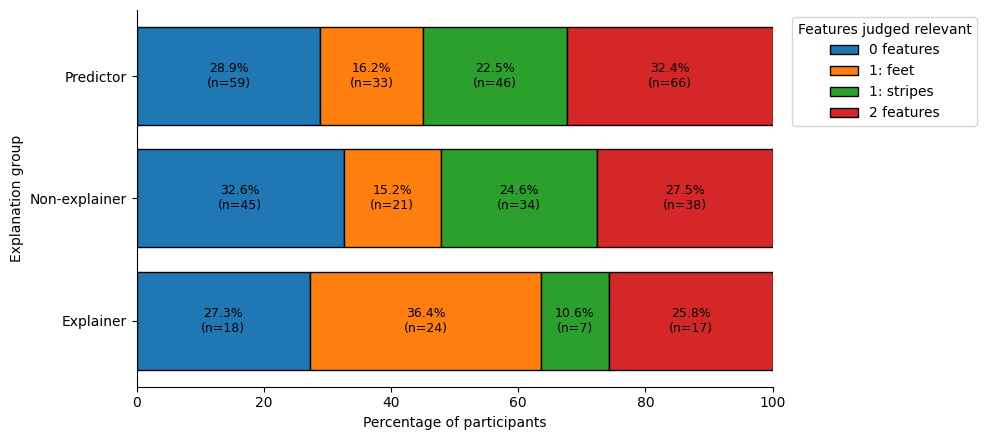

In [10]:
# ---------------------------------------------------------
# Subdivide the "1 feature" category by which feature
# was endorsed
# ---------------------------------------------------------

overfit_df["endorsement_pattern"] = np.select(
    [
        overfit_df["n_features_endorsed"].eq(0),

        (
            overfit_df["n_features_endorsed"].eq(1)
            & overfit_df["feet_endorsed"].eq(1)
        ),

        (
            overfit_df["n_features_endorsed"].eq(1)
            & overfit_df["stripes_endorsed"].eq(1)
        ),

        overfit_df["n_features_endorsed"].eq(2),
    ],
    [
        "0 features",
        "1: feet",
        "1: stripes",
        "2 features",
    ],
    default=pd.NA,
)


# Order of groups on the y-axis
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

# Order of segments from left to right
pattern_order = [
    "0 features",
    "1: feet",
    "1: stripes",
    "2 features",
]


# ---------------------------------------------------------
# Count participants in each endorsement pattern
# ---------------------------------------------------------

pattern_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "endorsement_pattern",
        ],
        observed=True,
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique",
        )
    )
    .reset_index()
)


# Add missing group × pattern combinations as zeros
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        pattern_order,
    ],
    names=[
        "explanation_group",
        "endorsement_pattern",
    ],
)

pattern_percentages = (
    pattern_percentages
    .set_index(
        [
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .reindex(
        full_index,
        fill_value=0,
    )
    .reset_index()
)


# Calculate percentages within each explanation group
pattern_percentages["percentage"] = (
    pattern_percentages["n_participants"]
    / pattern_percentages
        .groupby(
            "explanation_group"
        )["n_participants"]
        .transform("sum")
    * 100
)

print(pattern_percentages)


# ---------------------------------------------------------
# Convert counts and percentages to wide format
# ---------------------------------------------------------

count_wide = (
    pattern_percentages
    .pivot(
        index="explanation_group",
        columns="endorsement_pattern",
        values="n_participants",
    )
    .reindex(group_order)
    .reindex(
        columns=pattern_order,
        fill_value=0,
    )
    .fillna(0)
)


percentage_wide = (
    pattern_percentages
    .pivot(
        index="explanation_group",
        columns="endorsement_pattern",
        values="percentage",
    )
    .reindex(group_order)
    .reindex(
        columns=pattern_order,
        fill_value=0,
    )
    .fillna(0)
)


# ---------------------------------------------------------
# Horizontal 100% stacked bar chart
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.5))

left = np.zeros(len(percentage_wide))

for pattern in pattern_order:
    percentages = percentage_wide[pattern].to_numpy()
    counts = count_wide[pattern].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=pattern,
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        center = starting_point + percentage / 2

        # Show percentage and n for larger sections
        if percentage >= 10:
            ax.text(
                center,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )

        # Show just percentage for smaller sections
        elif percentage >= 4:
            ax.text(
                center,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages


ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))

# Put Predictor at the top
ax.invert_yaxis()

ax.legend(
    title="Features judged relevant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
print(
    df_long.groupby(
        ["feature_dimension", "feature_explanation_group"],
        dropna=False,
    ).size()
)

print(
    df_long.loc[
        df_long["had_causal_explanation_for_feature"],
        [
            "participant",
            "task",
            "explanation_type",
            "feature_dimension",
            "causal_feet",
            "causal_stripes",
            "feature_explanation_group",
        ],
    ].sort_values(["feature_dimension", "participant"]))

feature_dimension  feature_explanation_group
feet               explainer                     34
                   non_explainer                170
                   predictor                    204
stripes            explainer                     46
                   non_explainer                158
                   predictor                    204
dtype: int64
     participant         task explanation_type feature_dimension causal_feet  \
20             6  accommodate             feet              feet        True   
42             7  accommodate             both              feet        True   
202            9  accommodate             both              feet        True   
116           11  accommodate             feet              feet        True   
176           12  accommodate             both              feet        True   
..           ...          ...              ...               ...         ...   
438          215  accommodate          stripes           stripes      

In [14]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study4.csv'), index=False)

In [15]:
# Get testingresponses
df = df_combined[
    [
        "task",
        "conditionOrder",
        "testing_image_order",
        "testing_responses",
        "relevant_dim",
        "irrelevant_dim",
        "stripes_high",
        "feet_high",
        "explanation_type",
        "has_causal_explanation",
        "causal_stripes",
        "causal_feet",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "testing_image_order",
            "testing_responses",
        ]
    )
    .rename(
        columns={
            "testing_image_order": "item"
        }
    )
)

avg_food_test = df_long2.copy()

In [16]:
# Average training fertility score per item
df = df_combined[
    [
        "task",
        "training_image_order",
        "fertility_score",
        "conditionOrder",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "training_image_order",
            "fertility_score",
        ]
    )
    .rename(
        columns={
            "training_image_order": "item"
        }
    )
)

avg_food_train = (
    df_long2
    .groupby(
        [
            "task",
            "conditionOrder",
            "item",
        ],
        as_index=False,
    )["fertility_score"]
    .mean()
)

In [17]:
df_merged = avg_food_test.merge(#merge test and training fertility scores
    avg_food_train,
    on=[
        "task",
        "conditionOrder",
        "item",
    ],
    how="left",
    validate="many_to_one",
)

In [18]:
df_merged["testing_responses"] = pd.to_numeric(
    df_merged["testing_responses"],
    errors="coerce",
)

df_merged["fertility_score"] = pd.to_numeric(
    df_merged["fertility_score"],
    errors="coerce",
)

df_merged["error"] = (
    df_merged["testing_responses"]
    - df_merged["fertility_score"]
)

df_merged["abs_error"] = df_merged["error"].abs()

df_merged[["stripes", "feet"]] = (
    df_merged["item"]
    .str.split("_", expand=True)
)

df_merged["stripes_match_high"] = (
    df_merged["stripes"] == df_merged["stripes_high"]
).astype(int)

df_merged["feet_match_high"] = (
    df_merged["feet"] == df_merged["feet_high"]
).astype(int)

In [19]:
output_path = os.path.join(
    topdir,
    "data/Combined/df_merged_for_R-Study4.csv"
)

df_merged.to_csv(
    output_path,
    index=False,
)

In [20]:
participant_corrs = []

for (task, condition_order), g in df_merged.groupby(
    ["task", "conditionOrder"]
):
    for feat in ["stripes", "feet"]:

        match_col = f"{feat}_match_high"
        causal_col = f"causal_{feat}"
        high_col = f"{feat}_high"

        # Correlation between testing response and matching
        # the high value of this feature
        corr = g["testing_responses"].corr(
            g[match_col]
        )

        # Is this feature relevant for this participant?
        relevant = (
            g["relevant_dim"].iloc[0] == feat
        )

        # Did the participant explain this particular feature?
        had_causal_explanation_for_feature = bool(
            g[causal_col]
            .fillna(False)
            .iloc[0]
        )

        # Feature-relative explanation group
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": condition_order,
                "task": task,
                "explanation_type": (
                    g["explanation_type"].iloc[0]
                ),
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,
                "feature_explanation_group":
                    feature_explanation_group,
                "feature_dimension": feat,
                "high_value": g[high_col].iloc[0],
                "feature_relevance": (
                    "relevant"
                    if relevant
                    else "irrelevant"
                ),
                "correlation": corr,
                "irrelevant_dim": (
                    g["irrelevant_dim"].iloc[0]
                ),
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )

df_corr = pd.DataFrame(participant_corrs)

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/1856406433.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38058/1856406433.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3

In [21]:
df_corr.to_csv(os.path.join(outputdirCombined, 'df_corr_by_explanation_for_R-Study4.csv'), index=False)